In [14]:
import sys
sys.path.append("..")
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.loader import load_data

sns.set_theme(style="whitegrid")
prices, log_returns = load_data(config_path="../config/params.yaml")

Dropped 2 tickers (insufficient history): {'DOW', 'WBA'}


In [6]:
print(f"Price matrix : {prices.shape[0]} days x {prices.shape[1]} tickers")
print(f"Date range   : {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"Missing values (after cleaning): {prices.isna().sum().sum()}")
print(f"\nReturn stats (annualized):")
print(f"  Mean:   {log_returns.mean().mean() * 252:.2%}")
print(f"  Stdev:  {log_returns.std().mean() * np.sqrt(252):.2%}")

Price matrix : 1760 days x 98 tickers
Date range   : 2018-01-02 to 2024-12-30
Missing values (after cleaning): 0

Return stats (annualized):
  Mean:   10.41%
  Stdev:  30.44%


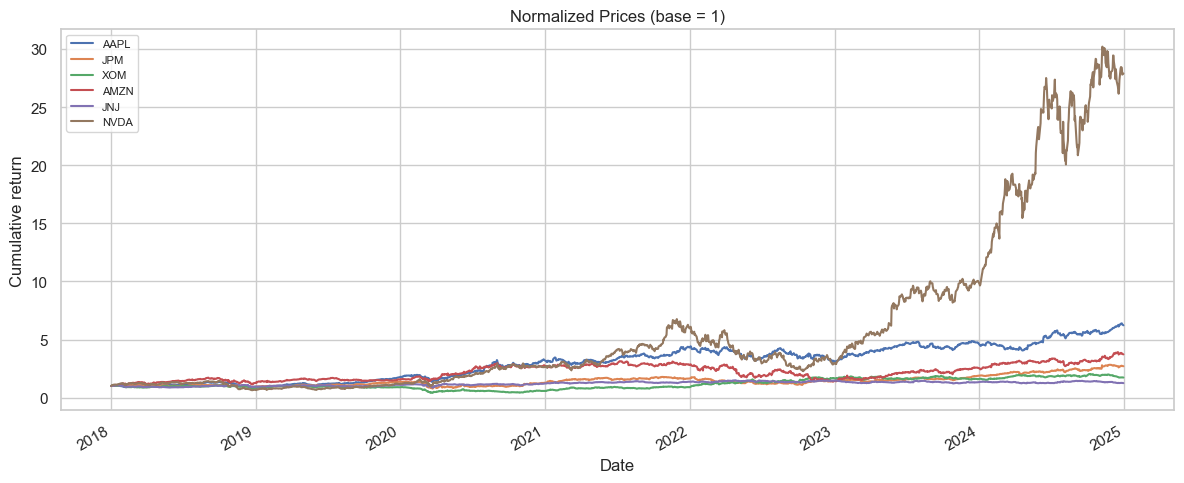

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
sample = ["AAPL", "JPM", "XOM", "AMZN", "JNJ", "NVDA"]
(prices[sample] / prices[sample].iloc[0]).plot(ax=ax)
ax.set_title("Normalized Prices (base = 1)")
ax.set_ylabel("Cumulative return")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [10]:
corr = log_returns.corr()
print(f"Median pairwise correlation: {corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().median():.3f}")

Median pairwise correlation: 0.386


Kurtosis (excess): 16.2


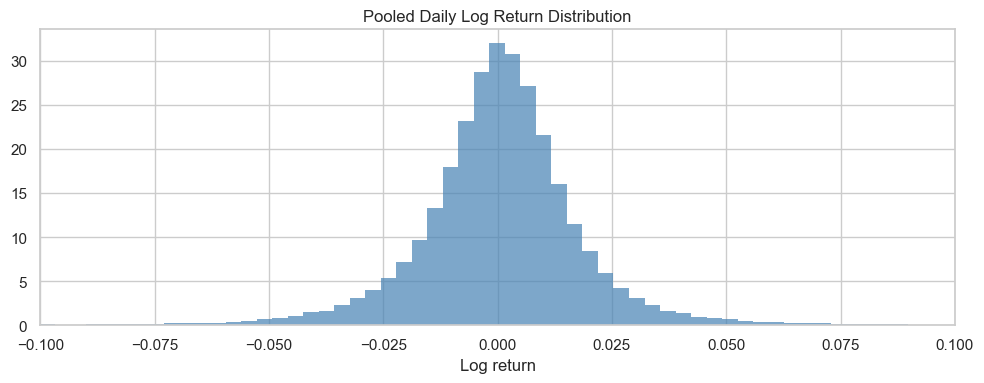

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
pooled = log_returns.values.flatten()
ax.hist(pooled, bins=200, density=True, alpha=0.7, color="steelblue", edgecolor="none")
ax.set_xlim(-0.10, 0.10)
ax.set_title("Pooled Daily Log Return Distribution")
ax.set_xlabel("Log return")
print(f"Kurtosis (excess): {float(pd.Series(pooled).kurtosis()):.1f}")
plt.tight_layout()
plt.show()